# cheaseBS at the campaign box edges

Does reshaping the profiles change how hard cheaseBS has to work?

Four solves per discharge: `Te_ped_scale` and `ne_ped_scale` at the frozen box
edges 0.7 and 1.3. Needs CHEASE, so this runs on NERSC.

**The open question.** The 2026-08-18 five-point 132543 run had four points
converging in 2 iterations and `ne` x1.3 needing 19, with no explanation. These
runs say whether that split follows the direction (up hard, down easy), the
variable (density hard, temperature easy), the discharge, or nothing
reproducible. The answer sets `max_iter` for the campaign, since a cap read off
the typical point truncates the hard one.

Each discharge gets its own cell: run, parameter/iteration table, then the
source gfile against its four reconstructions. **Start with 132543 and read the
output before running the rest.**

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib, sys

# Same root-walk the fit and scaling notebooks use, so this runs from any cwd.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pedestal_scan.py").exists())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "reshape_convergence"))

from pedestal_scan import Campaign
import reshape_helpers as rh

# Loads and fits all four baselines, so the fits under these solves are the
# same ones the fit and scaling notebooks scored.
camp = Campaign()
print("shots  ", camp.shots)
print("axes   ", rh.AXES)
print("scales ", rh.SCALES)
print("cheaseBS", rh.CHEASEBS)

[WARNING] TPED.projects.discharge_tools.src.discharge_data: time_ms mismatch: g129015.00409_450→409ms, p129015.00400_x8099→400ms  (files: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129015/g129015.00409_450, /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129015/p129015.00400_x8099)
[WARNING] TPED.projects.discharge_tools.src.discharge_data: time_ms mismatch: g129038.00400→110ms, p129038.00400→400ms  (files: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129038/g129038.00400, /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129038/p129038.00400)


shots   [129015, 129038, 132543, 132588]
axes    ('Te_ped_scale', 'ne_ped_scale')
scales  (0.7, 1.3)
cheaseBS {'max_iter': 25, 'tol_bs': 0.0001, 'tol_q': 0.0001, 'tol_ip_rel': 0.02, 'bootstrap_mix': 0.1, 'istar_mix': 0.05, 'plot_errors': True}


## 132543 — test discharge

ELMy, low triangularity, and the shot the 2-vs-19 split came from. Analysis
radii 0.736 / 0.825 are its q=4 and q=5 surfaces.

Read before running the others:
- **`iters`** — does 1.30 cost more than 0.70? does `ne` cost more than `Te`?
- **`accepted`** — an `R` or a `RAISED` inside the frozen box is a campaign
  blocker, not a note.
- **`Ip_err`** — compare +delta against -delta on one axis. A one-sided response
  is the open asymmetry.
- **the plot** — a reconstruction lying on top of the black source curve means
  the reshape never reached the equilibrium.

132543  radii (0.736, 0.825)  4 solves -> /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260824_19-43-24
  Te_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-43-25-Te_ped_scale_0.700/cheasebs_run_config.json
Starting iterative CHEASE workflow (coordinate=rhop, replay=istar, qspec=on)
Output directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-43-25-Te_ped_scale_0.700
Baseline directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-43-25-Te_ped_scale_0.700/cheasebs_baseline
Run targets: Ip=947061.789 A (source 947061.789 A), Bt=-0.439262 T (source -0.439262 T)
Rebuilding baseline decomposition from reference profiles
Preparing baseline inputs from g132543.00700
Baseline radial mapping complete
Baseline Step 1 complete: thermal/fast pressure split and Zeff
Baseline Step 2 complete: bootstrap/driven current decompositi

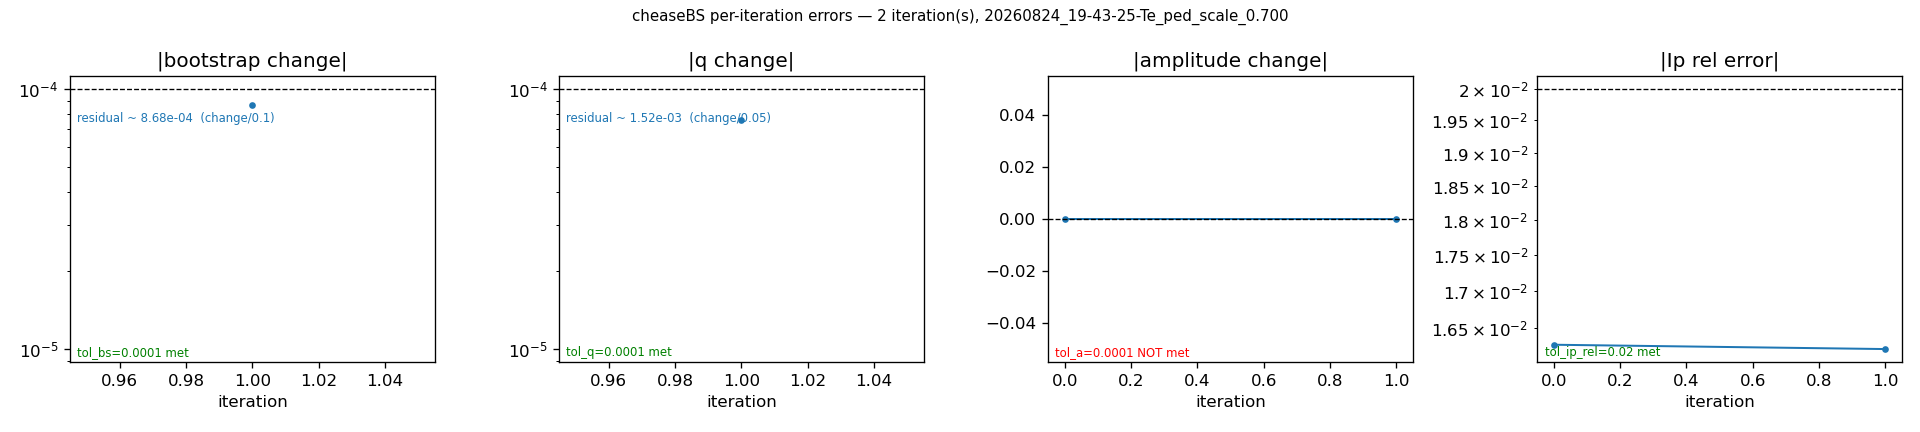

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-43-25-Te_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.622%  (final 931701.6 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.633%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.514%   (deviation from source)
[cheaseBS]   q95 error        0.834%
[cheaseBS]   q edge error    16.913%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-43-25-Te_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260824_19-43-24/Te_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 119s, accepted=True
  Te_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

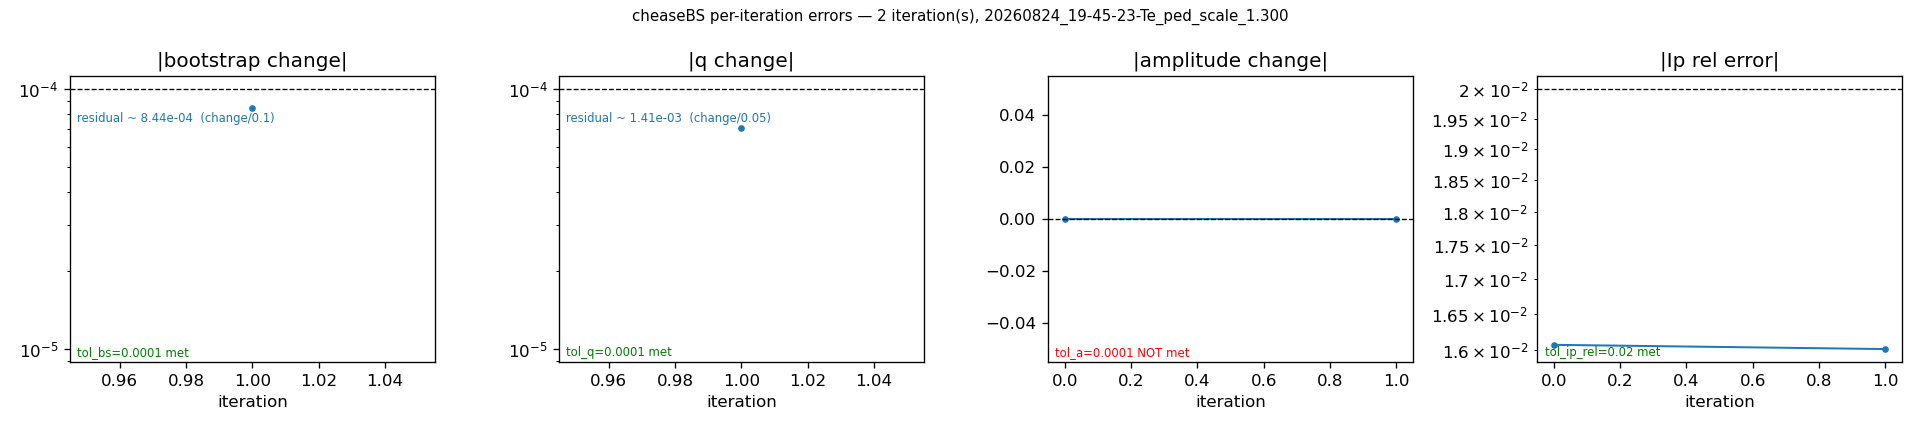

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-45-23-Te_ped_scale_1.300/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.601%  (final 931900.3 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.601%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.287%   (deviation from source)
[cheaseBS]   q95 error        0.874%
[cheaseBS]   q edge error    16.912%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-45-23-Te_ped_scale_1.300
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260824_19-43-24/Te_ped_scale_1.300/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 118s, accepted=True
  ne_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

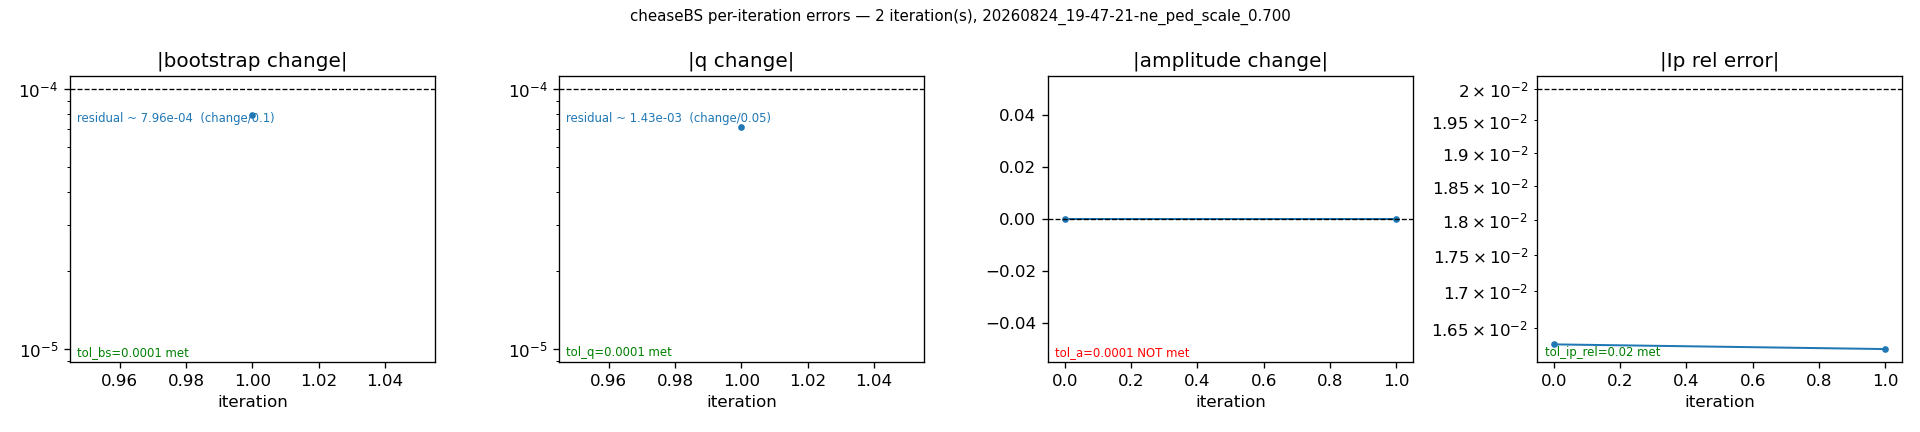

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-47-21-ne_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.622%  (final 931697.3 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.643%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.515%   (deviation from source)
[cheaseBS]   q95 error        0.834%
[cheaseBS]   q edge error    16.912%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-47-21-ne_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260824_19-43-24/ne_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 118s, accepted=True
  ne_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

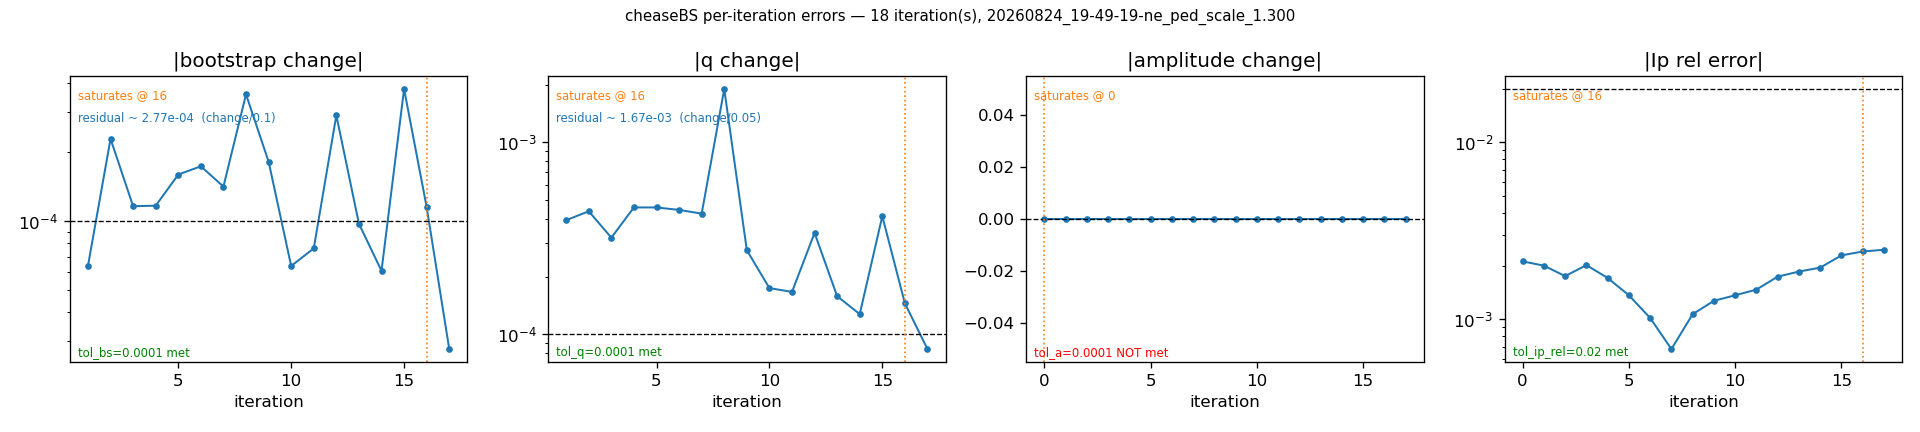

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-49-19-ne_ped_scale_1.300/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         0.247%  (final 949401.2 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   1.927%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   1.684%   (deviation from source)
[cheaseBS]   q95 error        0.008%
[cheaseBS]   q edge error    17.990%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (18 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_19-49-19-ne_ped_scale_1.300
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260824_19-43-24/ne_ped_scale_1.300/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 18 iters, 841s, accepted=True


shot,axis,scale,ped_top,ped_top/nom,iters,converged,accepted,Ip_err,q_err_max,q_edge_err,wall_s,status
132543,Te_ped_scale,0.700000,2.821e+02,0.913,2,True,True,1.62%,0.63%,16.91%,119,
132543,Te_ped_scale,1.300000,3.360e+02,1.087,2,True,True,1.60%,0.60%,16.91%,118,
132543,ne_ped_scale,0.700000,4.071e+19,0.732,2,True,True,1.62%,0.64%,16.91%,118,
132543,ne_ped_scale,1.300000,7.052e+19,1.268,18,True,True,0.25%,1.93%,17.99%,841,


In [2]:
rows_132543, wd = rh.run_bounds(camp, 132543)
rh.table(rows_132543, shot=132543)

In [3]:
fig = rh.plot_gfiles(rows_132543, camp, 132543)

In [4]:
# Pedestal zoom -- where the axes act, and where the q response should show.
fig = rh.plot_gfiles(rows_132543, camp, 132543, rho_tor=[0.7, 1.0])

## 132588 — ELM-free, high triangularity

Same radii as 132543. Its `ne` fit is pinned on the `b_pos` bound, so treat its `ne_ped_scale` rows as suspect until that is resolved.

132588  radii (0.736, 0.825)  4 solves -> /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132588_20260824_20-03-22
  Te_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-03-22-Te_ped_scale_0.700/cheasebs_run_config.json
Starting iterative CHEASE workflow (coordinate=rhop, replay=istar, qspec=on)
Output directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-03-22-Te_ped_scale_0.700
Baseline directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-03-22-Te_ped_scale_0.700/cheasebs_baseline
Run targets: Ip=983334.750 A (source 983334.750 A), Bt=-0.439205 T (source -0.439205 T)
Rebuilding baseline decomposition from reference profiles
Preparing baseline inputs from g132588.00650
Baseline radial mapping complete
Baseline Step 1 complete: thermal/fast pressure split and Zeff
Baseline Step 2 complete: bootstrap/driven current decompositi

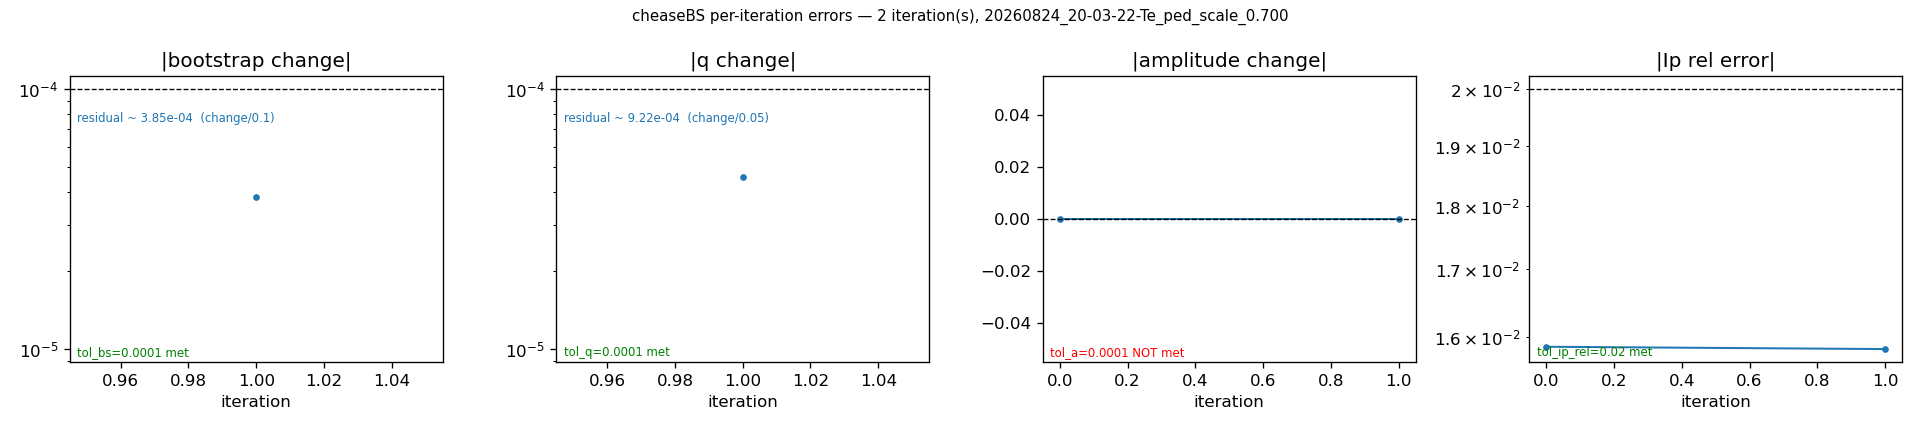

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-03-22-Te_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.582%  (final 967777.1 A vs reference 983334.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.351%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.756%   (deviation from source)
[cheaseBS]   q95 error        0.778%
[cheaseBS]   q edge error    19.908%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-03-22-Te_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132588_20260824_20-03-22/Te_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 128s, accepted=True
  Te_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

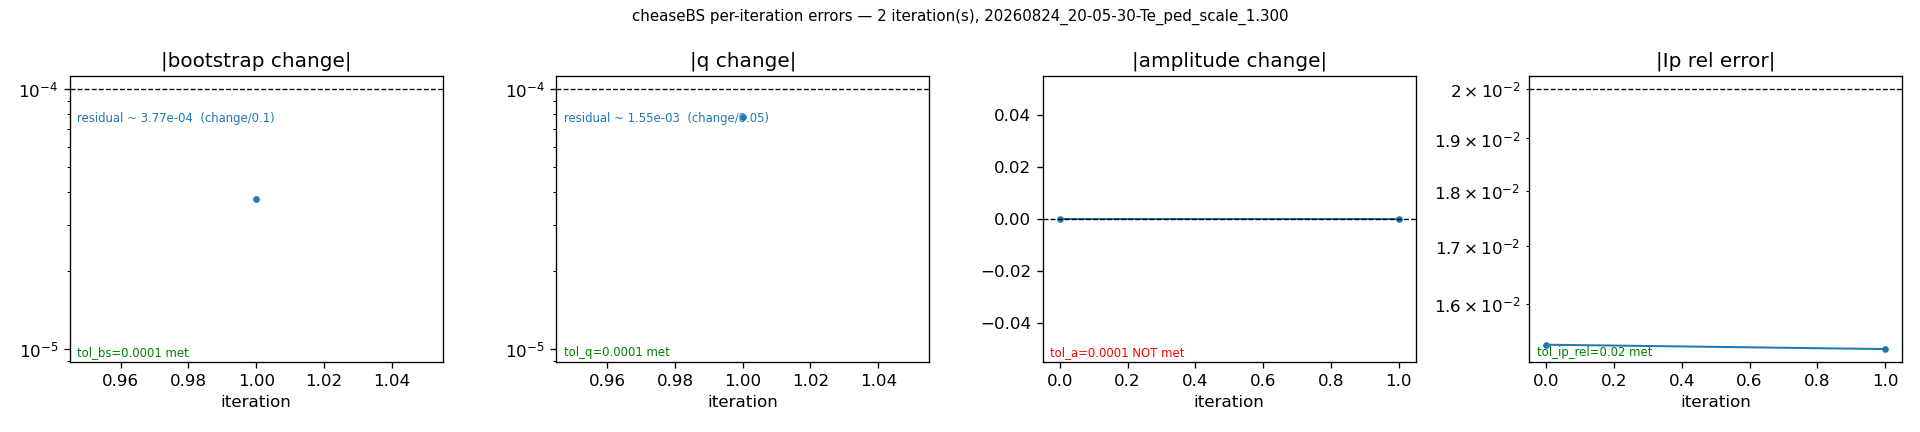

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-05-30-Te_ped_scale_1.300/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.527%  (final 968316.9 A vs reference 983334.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.360%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.739%   (deviation from source)
[cheaseBS]   q95 error        0.501%
[cheaseBS]   q edge error    19.936%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-05-30-Te_ped_scale_1.300
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132588_20260824_20-03-22/Te_ped_scale_1.300/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 130s, accepted=True
  ne_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

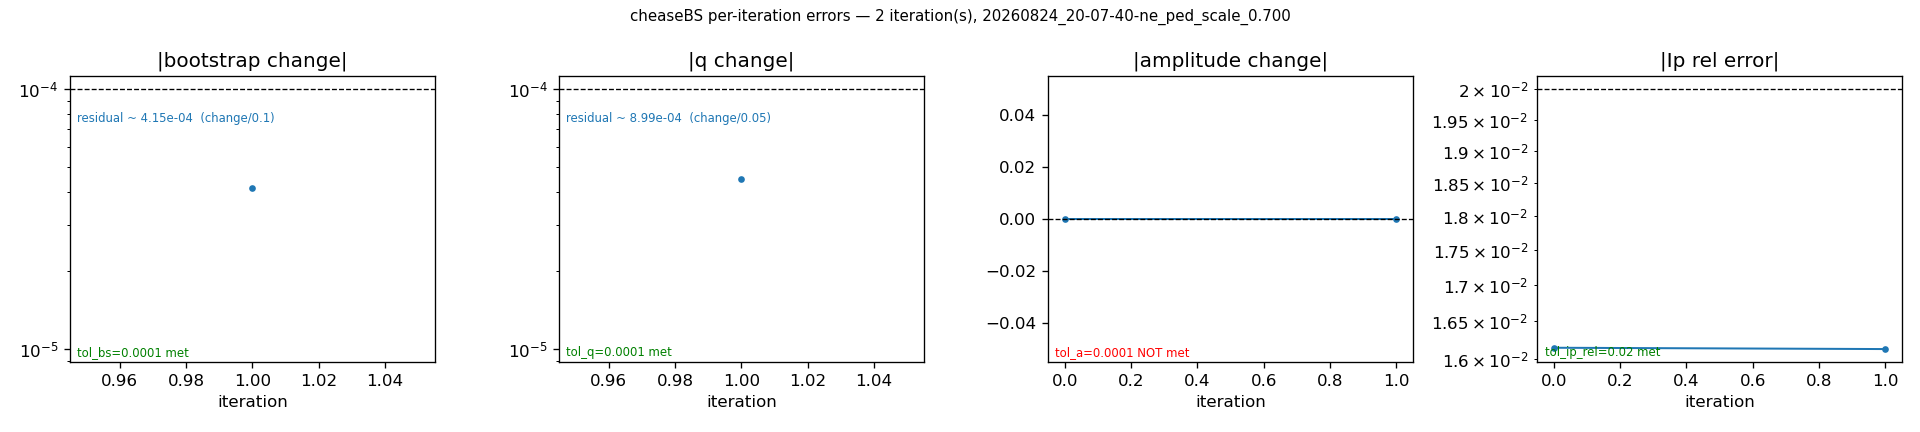

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-07-40-ne_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.613%  (final 967477.9 A vs reference 983334.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.390%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.835%   (deviation from source)
[cheaseBS]   q95 error        0.983%
[cheaseBS]   q edge error    19.892%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-07-40-ne_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132588_20260824_20-03-22/ne_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 130s, accepted=True
  ne_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

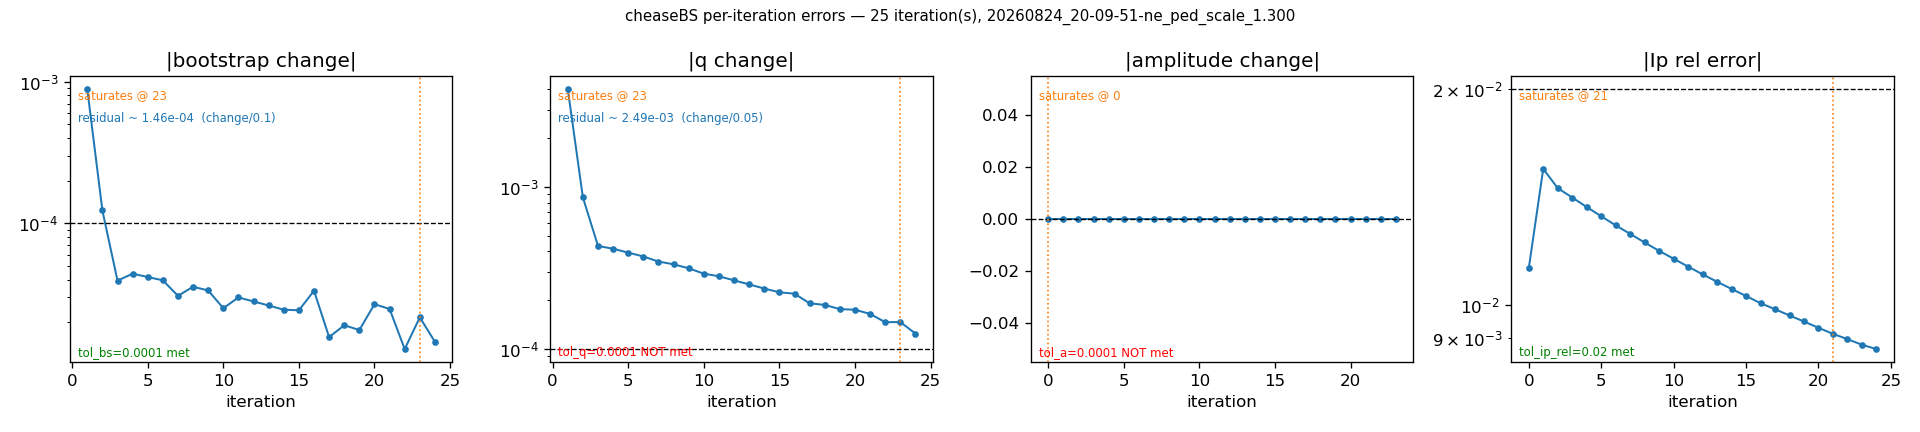

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-09-51-ne_ped_scale_1.300/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         0.868%  (final 974799.8 A vs reference 983334.8 A)
[cheaseBS]   q @ rho_tor 0.736   1.245%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   1.003%   (deviation from source)
[cheaseBS]   q95 error        0.036%
[cheaseBS]   q edge error    20.114%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=False (25 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-09-51-ne_ped_scale_1.300
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132588_20260824_20-03-22/ne_ped_scale_1.300/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 25 iters, 1145s, accepted=True


shot,axis,scale,ped_top,ped_top/nom,iters,converged,accepted,Ip_err,q_err_max,q_edge_err,wall_s,status
132588,Te_ped_scale,0.700000,1.474e+02,0.813,2,True,True,1.58%,0.76%,19.91%,128,
132588,Te_ped_scale,1.300000,2.154e+02,1.187,2,True,True,1.53%,0.74%,19.94%,130,
132588,ne_ped_scale,0.700000,5.280e+19,0.865,2,True,True,1.61%,0.83%,19.89%,130,
132588,ne_ped_scale,1.300000,6.925e+19,1.135,25,False,True,0.87%,1.24%,20.11%,1145,


In [5]:
rows_132588, wd = rh.run_bounds(camp, 132588)
rh.table(rows_132588, shot=132588)

In [6]:
fig = rh.plot_gfiles(rows_132588, camp, 132588, rho_tor=[0.7, 1.0])

## 129015 — ELMy, low triangularity

Single analysis radius 0.85.

129015  radii (0.85,)  4 solves -> /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/129015_20260824_20-28-57
  Te_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-28-57-Te_ped_scale_0.700/cheasebs_run_config.json
Starting iterative CHEASE workflow (coordinate=rhop, replay=istar, qspec=on)
Output directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-28-57-Te_ped_scale_0.700
Baseline directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-28-57-Te_ped_scale_0.700/cheasebs_baseline
Run targets: Ip=753908.302 A (source 753908.302 A), Bt=-0.475509 T (source -0.475509 T)
Rebuilding baseline decomposition from reference profiles
Preparing baseline inputs from g129015.00409
Baseline radial mapping complete
Baseline Step 1 complete: thermal/fast pressure split and Zeff
Baseline Step 2 complete: bootstrap/driven current decomposition
Base

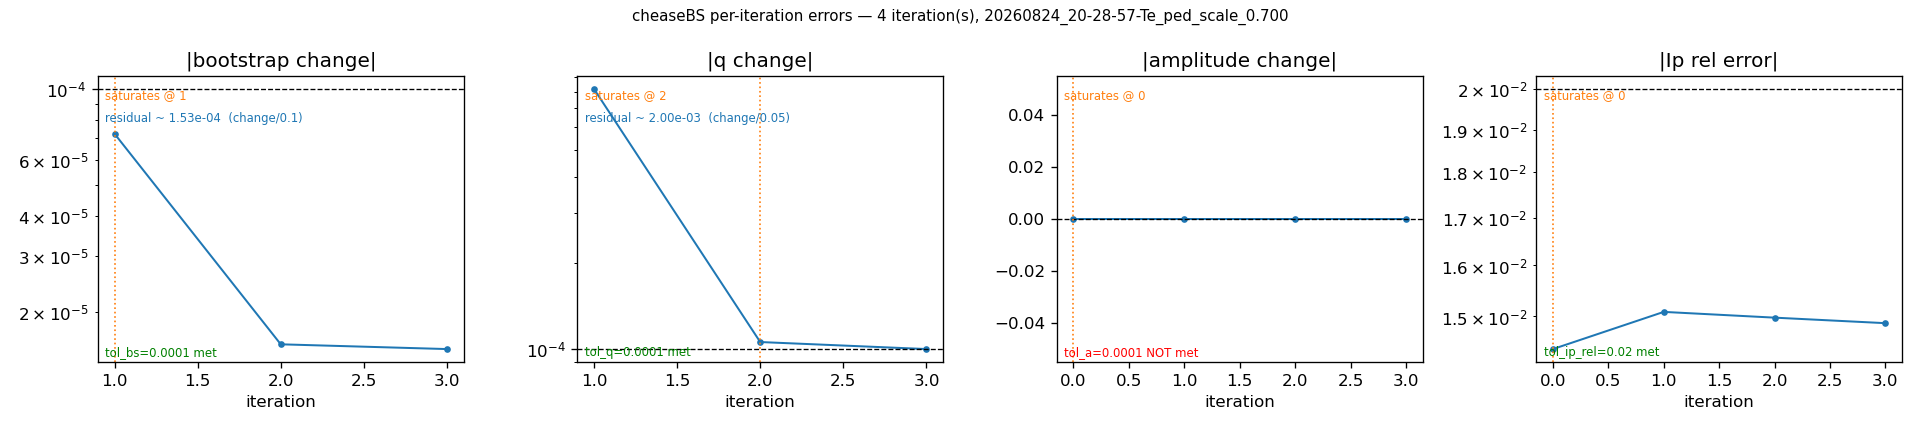

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-28-57-Te_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.487%  (final 742694.8 A vs reference 753908.3 A)
[cheaseBS]   q @ rho_tor 0.85    0.191%   (deviation from source)
[cheaseBS]   q95 error        0.677%
[cheaseBS]   q edge error    10.406%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (4 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260824_20-28-57-Te_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/129015_20260824_20-28-57/Te_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 4 iters, 196s, accepted=True
  Te_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheas

In [ ]:
rows_129015, wd = rh.run_bounds(camp, 129015)
rh.table(rows_129015, shot=129015)

In [ ]:
fig = rh.plot_gfiles(rows_129015, camp, 129015, rho_tor=[0.7, 1.0])

## 129038 — ELM-free, low triangularity

Weakest fit of the four and a placeholder analysis radius, so its gate verdict carries less weight than the other three.

In [ ]:
rows_129038, wd = rh.run_bounds(camp, 129038)
rh.table(rows_129038, shot=129038)

In [ ]:
fig = rh.plot_gfiles(rows_129038, camp, 129038, rho_tor=[0.7, 1.0])

## All four together

In [ ]:
import pandas as pd
allrows = [(s, r) for s, rs in [(132543, rows_132543), (132588, rows_132588),
                                (129015, rows_129015), (129038, rows_129038)]
           for r in rs]
pd.DataFrame([{"shot": s, "axis": r["axis"], "scale": r["scale"],
               "iters": r.get("iterations"), "accepted": r.get("accepted"),
               "wall_s": round(r.get("wall_s", float("nan")))} for s, r in allrows]
             ).pivot_table(index=["shot", "axis"], columns="scale",
                           values="iters", dropna=False)